Import Library


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [36]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler

# Load your CSV file
df = pd.read_csv('student dropout.csv')

# Separate features and label
X = df.drop('Dropped_Out', axis=1)
y = df['Dropped_Out']

# Apply random oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Combine resampled features and label into a DataFrame
df_balanced = pd.concat([X_resampled, y_resampled], axis=1)

# Save to a new CSV file
df_balanced.to_csv('student dropout balanced.csv', index=False)

print(df_balanced['Dropped_Out'].value_counts())


Dropped_Out
False    549
True     549
Name: count, dtype: int64


In [38]:
df=pd.read_csv("student dropout balanced.csv")

Exploratory Data Analysis (EDA)

In [39]:
df.shape

(1098, 38)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   School                       1098 non-null   object
 1   Gender                       1098 non-null   object
 2   Age                          1098 non-null   int64 
 3   Address                      1098 non-null   object
 4   Family_Size                  1098 non-null   object
 5   Parental_Status              1098 non-null   object
 6   Mother_Education             1098 non-null   int64 
 7   Father_Education             1098 non-null   int64 
 8   Mother_Job                   1098 non-null   object
 9   Father_Job                   1098 non-null   object
 10  Reason_for_Choosing_School   1098 non-null   object
 11  Guardian                     1098 non-null   object
 12  Travel_Time                  1098 non-null   int64 
 13  Study_Time                   1098

In [41]:
df.isnull().sum().sort_values(ascending=True)

School                         0
Gender                         0
Age                            0
Address                        0
Family_Size                    0
Parental_Status                0
Mother_Education               0
Father_Education               0
Mother_Job                     0
Father_Job                     0
Reason_for_Choosing_School     0
Guardian                       0
Travel_Time                    0
Study_Time                     0
Number_of_Failures             0
School_Support                 0
Family_Support                 0
Extra_Paid_Class               0
Extra_Curricular_Activities    0
Attended_Nursery               0
Wants_Higher_Education         0
Internet_Access                0
In_Relationship                0
Family_Relationship            0
Free_Time                      0
Going_Out                      0
Weekend_Alcohol_Consumption    0
Weekday_Alcohol_Consumption    0
Health_Status                  0
Number_of_Absences             0
Grade_1   

In [42]:
df.head(10)

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Anxiety_Score,Depression_Score,Stress_Score,Total_MH_Score,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,0,11,11,6,0,6,1,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,2,9,11,11,3,0,0,3,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,6,12,13,12,7,1,6,14,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,5,0,14,14,14,4,8,9,21,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,5,0,11,13,13,6,2,4,12,False
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,6,12,12,13,9,0,5,14,False
6,GP,M,16,U,LE3,T,2,2,other,other,...,3,0,13,12,13,2,4,9,15,False
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,1,2,10,13,13,6,6,6,18,False
8,GP,M,15,U,LE3,A,3,2,services,other,...,1,0,15,16,17,7,5,4,16,False
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,0,12,12,13,4,0,6,10,False


In [43]:
df.describe

<bound method NDFrame.describe of      School Gender  Age Address Family_Size Parental_Status  Mother_Education  \
0        GP      F   18       U         GT3               A                 4   
1        GP      F   17       U         GT3               T                 1   
2        GP      F   15       U         LE3               T                 1   
3        GP      F   15       U         GT3               T                 4   
4        GP      F   16       U         GT3               T                 3   
...     ...    ...  ...     ...         ...             ...               ...   
1093     MS      F   18       U         GT3               A                 2   
1094     MS      F   18       U         GT3               A                 2   
1095     MS      F   18       U         GT3               T                 1   
1096     MS      F   19       U         GT3               T                 1   
1097     MS      M   17       U         GT3               T                

📊 Data Visualization

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

Histogram


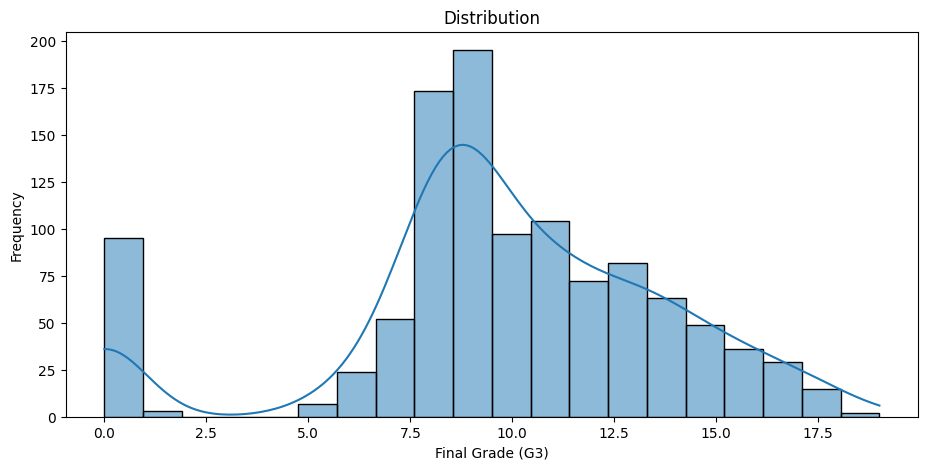

In [45]:
plt.figure(figsize=(11, 5))
sns.histplot(df['Final_Grade'], bins=20, kde=True)
plt.title('Distribution')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

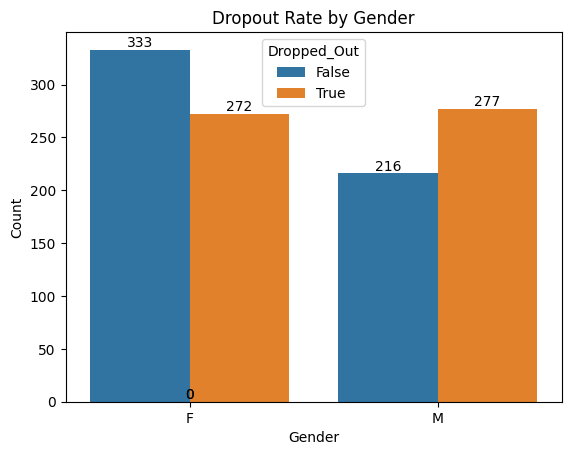

In [46]:
# Create the count plot
ax = sns.countplot(data=df, x='Gender', hue='Dropped_Out')

# Add values above bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            int(bar.get_height()), ha='center', va='bottom')

# Add title and labels
plt.title('Dropout Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Show the plot
plt.show()



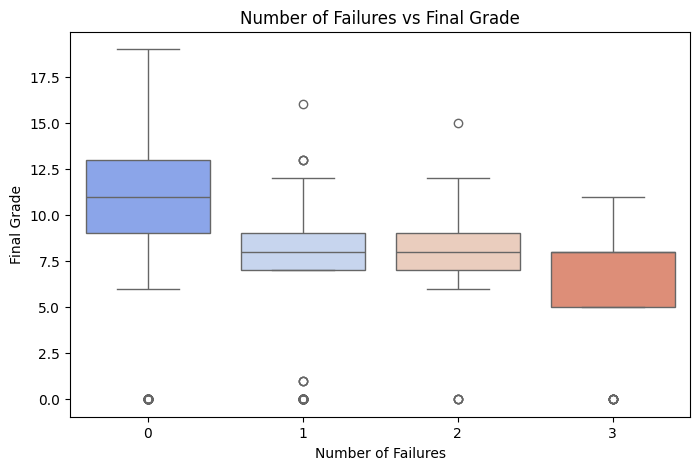

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Number_of_Failures', y='Final_Grade', palette='coolwarm')
plt.title('Number of Failures vs Final Grade')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade')
plt.show()

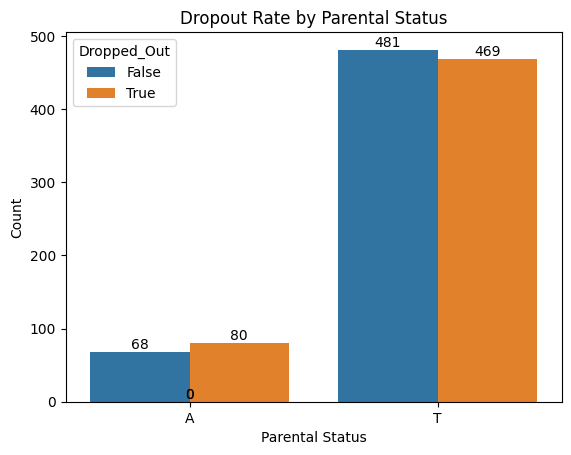

In [48]:
ax = sns.countplot(data=df, x='Parental_Status', hue='Dropped_Out')

# Add title and labels
plt.title('Dropout Rate by Parental Status')
plt.xlabel('Parental Status')
plt.ylabel('Count')

# Add values above each bar
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            int(bar.get_height()), ha='center', va='bottom')

# Show the plot
plt.show()



Note on Parental_Status values
The column Parental_Status shows whether a student’s parents are together or not.

T → Together (parents are living together/married)

A → Apart (parents are separated/divorced)

In [49]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [50]:
categorical_cols

Index(['School', 'Gender', 'Address', 'Family_Size', 'Parental_Status',
       'Mother_Job', 'Father_Job', 'Reason_for_Choosing_School', 'Guardian',
       'School_Support', 'Family_Support', 'Extra_Paid_Class',
       'Extra_Curricular_Activities', 'Attended_Nursery',
       'Wants_Higher_Education', 'Internet_Access', 'In_Relationship'],
      dtype='object')

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [52]:
#encoding
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
encoder=LabelEncoder()
df[categorical_cols]=encoder.fit_transform(categorical_cols)

In [53]:
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Anxiety_Score,Depression_Score,Stress_Score,Total_MH_Score,Dropped_Out
0,14,7,18,0,4,12,4,4,11,6,...,3,4,0,11,11,6,0,6,1,False
1,14,7,17,0,4,12,1,1,11,6,...,3,2,9,11,11,3,0,0,3,False
2,14,7,15,0,4,12,1,1,11,6,...,3,6,12,13,12,7,1,6,14,False
3,14,7,15,0,4,12,4,2,11,6,...,5,0,14,14,14,4,8,9,21,False
4,14,7,16,0,4,12,3,3,11,6,...,5,0,11,13,13,6,2,4,12,False


In [54]:
# Define features and target
X = df.drop('Dropped_Out', axis=1)
y = df['Dropped_Out']

Training and Testing sets

In [55]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)#not fit transform

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Model Training 

In [57]:
# Initialize the model
model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Add hidden layers
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))

# Add output layer
model.add(Dense(units=1, activation='sigmoid'))

In [58]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7568 - loss: 0.4857 - val_accuracy: 0.8121 - val_loss: 0.3858
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.3126 - val_accuracy: 0.9273 - val_loss: 0.2285
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9377 - loss: 0.2108 - val_accuracy: 0.9333 - val_loss: 0.1793
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9438 - loss: 0.1781 - val_accuracy: 0.9818 - val_loss: 0.1533
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9605 - loss: 0.1498 - val_accuracy: 0.9273 - val_loss: 0.1564
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9544 - loss: 0.1343 - val_accuracy: 0.9394 - val_loss: 0.1344
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9681 - loss: 0.1174 - val_accuracy: 0.9818 - val_loss: 0.1230
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9681 - loss: 0.1114 - val_accuracy: 0.9333 - val_loss:

In [59]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Accuracy: {test_accuracy}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9891 - loss: 0.0718 
Accuracy: 0.9890909194946289


In [60]:

from sklearn.svm import SVC


# Support Vector Machine (SVM)
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
print("SVM Accuracy:", svm.score(X_test, y_test))


SVM Accuracy: 0.9563636363636364


In [61]:

from sklearn.neighbors import KNeighborsClassifier


# K-Nearest Neighbors Classifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("KNN Accuracy:", knn.score(X_test, y_test))


KNN Accuracy: 0.9345454545454546


In [62]:
from sklearn.naive_bayes import GaussianNB


# Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train, y_train)
print("Naive Bayes Accuracy:", nb.score(X_test, y_test))



Naive Bayes Accuracy: 0.9163636363636364


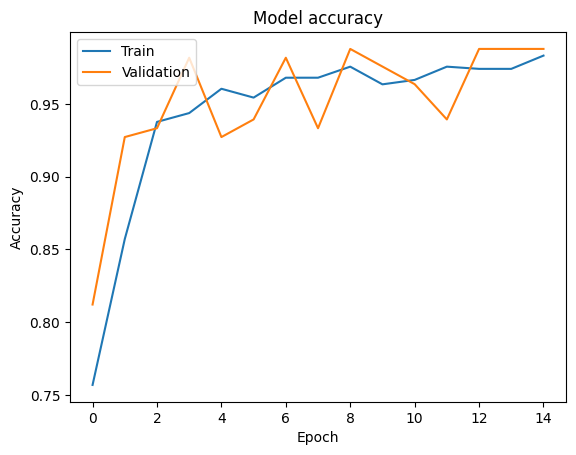

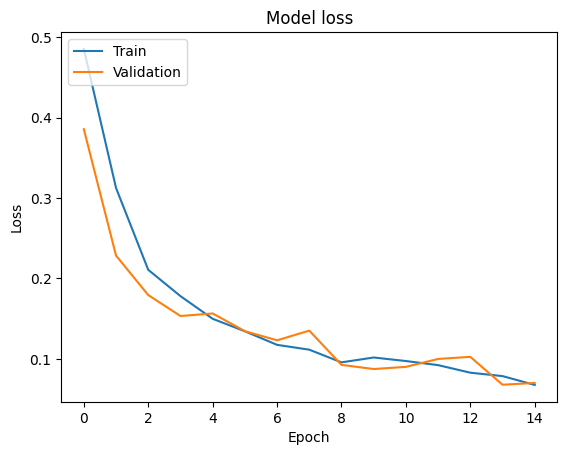

In [63]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()